# SimPy - Bike Sharing System
In Lab 2, we introduced the basics of modeling and simulation by creating a simplified bike-sharing system using basic Python classes. We modeled stations, bikes, and trips between stations with probabilities, and analyzed the system over a 30-minute period.

In Lab 3, we will take a step further by introducing SimPy, a powerful Python library for discrete-event simulation. SimPy allows us to model complex systems more efficiently and accurately. We will reimplement our bike-sharing system using SimPy and explore extensions and upgrades to enhance the system.


### Pip packages
Pip is python's built-in package manager - it helps us install libraries that are not packaged inside Python's vanilla distribution.

Perhaps the only pip command you need to know for this laboratory is pip install {package_name}. E.g. pip install simpy.
This will download the necessary prerequisites, install them and make the library available for use using python's module import functionality.


```
import simpy
```

The pip commands only work in the terminal/command line, they are not python code. Jupyter notebooks (and hence Google Colab) environments allow calling commands in the terminal by adding an exclamation mark as a prefix:
```
!pip install simpy
```


In [43]:
%pip install simpy

Note: you may need to restart the kernel to use updated packages.


SimPy is a process-based discrete-event simulation framework based on standard Python. It allows you to model systems where events occur at discrete points in time, making it ideal for simulating real-world processes like bike-sharing systems, queuing systems, network traffic, and more.

Keywords when working with simpy:

* Environment: Keep track of simulation time and schedule events.
* Processes: Simulate concurrent activities in the system.
* Events: Model the occurrence of incidents at specific times.
* Resources: Manage limited resources like bikes and docks.


In [44]:
import simpy
import random
import matplotlib.pyplot as plt

# The Environment in SimPy manages the simulation time and handles event scheduling. It acts as the central controller of the simulation.
env = simpy.Environment()

# Processes are functions that yield events. They simulate the behavior of active components in the system, like customers, machines, or in our case, bikes and trips.
# Example of a simple process
def simple_process(env):
    while True:
        print(f"Time {env.now}: Process is running")
        yield env.timeout(1)  # Wait for 1 time unit


# To start a process in SimPy, you add it to the environment:
env.process(simple_process(env))


<Process(simple_process) object at 0x1dd122ab4d0>

SimPy provides **resource** classes to model limited capacity constraints. Resources represent entities like servers, parking spaces, or bikes.

* Resource: A generic resource with a limited number of slots.
* Container: Represents the production and consumption of a homogeneous, undistinguishable bulk (like water in a tank).
* Store: A resource where each item is distinct (e.g., individual bikes with unique IDs).

For our bike-sharing system, we can use Container to represent the number of bikes at a station.

### Reimplementing the Bike Share System with SimPy

Defining the System Components
* Stations: Entities with a capacity (number of docks) and a container for bikes.
* Bikes: Represented as tokens in containers; we don't need to model individual bikes.
* Trips: Processes that simulate the movement of bikes between stations.

In [45]:
# Defining the Station Class
class Station:
    def __init__(self, env, name, capacity, init_bikes):
        self.env = env
        self.name = name
        self.capacity = capacity
        self.bikes = simpy.Container(env, init=init_bikes, capacity=capacity)

In [46]:
# Defining the Bike Trip Process
def bike_trip(env, from_station, to_station, trip_duration):
    if from_station.bikes.level > 0:
        yield from_station.bikes.get(1)
        print(f"Time {env.now}: Bike taken from {from_station.name}")
    else:
        print(f"Time {env.now}: No bikes available at {from_station.name}")
        return  # Trip cannot proceed without a bike

    # Simulate the trip duration
    yield env.timeout(trip_duration)

    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        print(f"Time {env.now}: Bike returned to {to_station.name}")
    else:
        print(f"Time {env.now}: No docks available at {to_station.name}, returning bike to {from_station.name}")
        yield env.timeout(trip_duration)
        if from_station.bikes.level > 0:
            yield from_station.bikes.put(1)
            print(f"Time {env.now}: Bike returned to {from_station.name}")
        # For simplicity, the bike is returned to original station - if there are no empty slots, we lose the bike

In [47]:
# Defining the Trip Generation Process
"""
The function generate_trips continuously checks if trips should occur between stations based on specified probabilities.
For each possible trip, it generates a random number and compares it with the trip probability.
If a trip is to occur, it starts a bike_trip process.
"""
def generate_trips(env, prob_matrix):
    while True:
        # Decide whether a trip occurs based on probabilities
        for (from_station, to_station), prob in prob_matrix.items():
            if random.uniform(0, 1) < prob:
                trip_duration = 1  # Fixed trip duration for simplicity
                env.process(bike_trip(env, from_station, to_station, trip_duration))
        yield env.timeout(1)  # Wait for 1 minute before checking again

In [48]:
# Setting Up Stations and Probabilities

# Create stations
upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
center_station = Station(env, "Center", capacity=10, init_bikes=5)

stations = [upt_station, center_station]

# Define trip probabilities
prob_matrix = {
    (upt_station, center_station): 0.3,  # 30% chance per minute
    (center_station, upt_station): 0.5,  # 50% chance per minute
}


In [49]:
# Running the Simulation

# Start the trip generation process
env.process(generate_trips(env, prob_matrix))

# Run the simulation for 30 minutes
env.run(until=30)

Time 0: Process is running
Time 0: Bike taken from Center
Time 1: Process is running
Time 1: Bike taken from Center
Time 1: Bike returned to UPT
Time 2: Process is running
Time 2: Bike taken from UPT
Time 2: Bike returned to UPT
Time 3: Process is running
Time 3: Bike returned to Center
Time 4: Process is running
Time 5: Process is running
Time 6: Process is running
Time 7: Process is running
Time 7: Bike taken from Center
Time 8: Process is running
Time 8: Bike taken from UPT
Time 8: Bike returned to UPT
Time 9: Process is running
Time 9: Bike returned to Center
Time 10: Process is running
Time 10: Bike taken from UPT
Time 10: Bike taken from Center
Time 11: Process is running
Time 11: Bike taken from Center
Time 11: Bike returned to Center
Time 11: Bike returned to UPT
Time 12: Process is running
Time 12: Bike taken from UPT
Time 12: Bike taken from Center
Time 12: Bike returned to UPT
Time 13: Process is running
Time 13: Bike taken from Center
Time 13: Bike returned to Center
Time 1

**Collecting Data**

We need to record the number of bikes at each station over time for analysis. We'll create **a monitoring process** for this purpose.

In [50]:
def monitor_stations(env, stations, bike_levels):
    while True:
        for station in stations:
            bike_levels[station.name].append((env.now, station.bikes.level))
        yield env.timeout(1)

In [51]:
# Since we've added new processes, we should reset the environment and reinitialize everything.
env = simpy.Environment()

# Reinitialize stations
upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
center_station = Station(env, "Center", capacity=10, init_bikes=5)
stations = [upt_station, center_station]

# Reinitialize the probability matrix
prob_matrix = {
    (upt_station, center_station): 0.3,
    (center_station, upt_station): 0.5,
}

# Reinitialize the bike_levels dictionary
bike_levels = {station.name: [] for station in stations}

# Start the processes
env.process(generate_trips(env, prob_matrix))
env.process(monitor_stations(env, stations, bike_levels))

# Run the simulation
env.run(until=30)

Time 0: Bike taken from Center
Time 1: Bike returned to UPT
Time 4: Bike taken from UPT
Time 4: Bike taken from Center
Time 5: Bike taken from UPT
Time 5: Bike returned to Center
Time 5: Bike returned to UPT
Time 6: Bike taken from Center
Time 6: Bike returned to Center
Time 7: Bike taken from Center
Time 7: Bike returned to UPT
Time 8: Bike taken from Center
Time 8: Bike returned to UPT
Time 9: Bike taken from UPT
Time 9: Bike returned to UPT
Time 10: Bike taken from Center
Time 10: Bike returned to Center
Time 11: Bike taken from Center
Time 11: Bike returned to UPT
Time 12: Bike taken from Center
Time 12: Bike returned to UPT
Time 13: No bikes available at Center
Time 13: Bike returned to UPT
Time 14: Bike taken from UPT
Time 15: Bike returned to Center
Time 16: Bike taken from UPT
Time 17: Bike returned to Center
Time 18: Bike taken from Center
Time 19: Bike taken from Center
Time 19: Bike returned to UPT
Time 20: Bike returned to UPT
Time 21: No bikes available at Center
Time 22: 

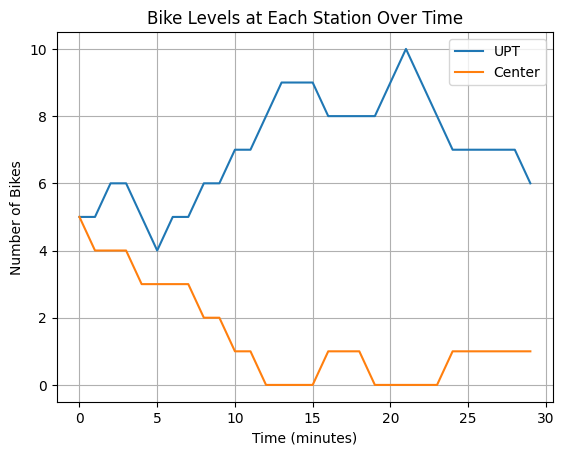

In [52]:
# Plotting the bike levels over time
for station_name, levels in bike_levels.items():
    times, counts = zip(*levels)
    plt.plot(times, counts, label=station_name)

plt.xlabel('Time (minutes)')
plt.ylabel('Number of Bikes')
plt.title('Bike Levels at Each Station Over Time')
plt.legend()
plt.grid(True)
plt.show()

### Extensions and Upgrades
Now that we have a working simulation, let's explore some extensions to make the system more realistic.

### Extension 1: Adding More Stations
Let's add a new station called "P700".

In [53]:
# Create new station
# Reset environment for this extension
env = simpy.Environment()

# Create three stations now
upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
center_station = Station(env, "Center", capacity=10, init_bikes=5)
p700_station = Station(env, "P700", capacity=8, init_bikes=4)

stations = [upt_station, center_station, p700_station]

# Update probability matrix with new station
prob_matrix = {
    (upt_station, center_station): 0.3,
    (center_station, upt_station): 0.5,
    (upt_station, p700_station): 0.2,      # UPT to P700
    (p700_station, upt_station): 0.25,     # P700 to UPT
    (center_station, p700_station): 0.15,  # Center to P700
    (p700_station, center_station): 0.2,   # P700 to Center
}


### Extension 2: Introducing Variable Trip Durations
Instead of fixed trip durations, we can have random durations.

In [54]:
# Introduce variable trip durations into bike trips
# Modify the bike_trip function to use random durations
def bike_trip_variable(env, from_station, to_station, unhappy_tracker=None):
    # Random trip duration between 1 and 5 minutes
    trip_duration = random.randint(1, 5)
    
    if from_station.bikes.level > 0:
        yield from_station.bikes.get(1)
        print(f"Time {env.now}: Bike taken from {from_station.name} (trip will take {trip_duration} min)")
    else:
        print(f"Time {env.now}: No bikes available at {from_station.name}")
        if unhappy_tracker is not None:
            unhappy_tracker['pickup_failed'] += 1
        return

    # Simulate the trip duration
    yield env.timeout(trip_duration)

    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        print(f"Time {env.now}: Bike returned to {to_station.name}")
    else:
        print(f"Time {env.now}: No docks available at {to_station.name}")
        if unhappy_tracker is not None:
            unhappy_tracker['return_failed'] += 1
        # Try to return to original station
        yield env.timeout(trip_duration)
        if from_station.bikes.level < from_station.capacity:
            yield from_station.bikes.put(1)
            print(f"Time {env.now}: Bike returned to {from_station.name}")

# Update generate_trips to use variable durations
def generate_trips_variable(env, prob_matrix, unhappy_tracker=None):
    while True:
        for (from_station, to_station), prob in prob_matrix.items():
            if random.uniform(0, 1) < prob:
                env.process(bike_trip_variable(env, from_station, to_station, unhappy_tracker))
        yield env.timeout(1)


### Extension 3: Implementing Rebalancing
Introduce a process that periodically moves bikes to balance the stations.

In [55]:
# Add stations rebalancing
def rebalance_stations(env, stations, rebalance_interval=10):
    """
    Periodically rebalance bikes across stations.
    Moves bikes from overstocked to understocked stations.
    """
    while True:
        yield env.timeout(rebalance_interval)
        
        print(f"\n--- Time {env.now}: Rebalancing started ---")
        
        # Calculate average bikes per station
        total_bikes = sum(station.bikes.level for station in stations)
        avg_bikes = total_bikes / len(stations)
        
        # Identify overstocked and understocked stations
        overstocked = [s for s in stations if s.bikes.level > avg_bikes + 1]
        understocked = [s for s in stations if s.bikes.level < avg_bikes - 1]
        
        # Move bikes from overstocked to understocked
        for from_station in overstocked:
            for to_station in understocked:
                # Calculate how many to move
                excess = int(from_station.bikes.level - avg_bikes)
                deficit = int(avg_bikes - to_station.bikes.level)
                bikes_to_move = min(excess, deficit, 2)  # Move max 2 bikes at a time
                
                if bikes_to_move > 0 and to_station.bikes.level + bikes_to_move <= to_station.capacity:
                    yield from_station.bikes.get(bikes_to_move)
                    yield to_station.bikes.put(bikes_to_move)
                    print(f"Time {env.now}: Moved {bikes_to_move} bike(s) from {from_station.name} to {to_station.name}")
        
        print(f"--- Time {env.now}: Rebalancing completed ---\n")


### Extension 4: Analyzing Unhappy Customers
Track the number of times a customer cannot rent or return a bike.

Running simulations without rebalancing...
Time 0: Bike taken from UPT (trip will take 3 min)
Time 2: Bike taken from Center (trip will take 3 min)
Time 2: Bike taken from UPT (trip will take 4 min)
Time 2: Bike taken from P700 (trip will take 1 min)
Time 3: Bike returned to Center
Time 3: Bike taken from UPT (trip will take 3 min)
Time 3: Bike taken from Center (trip will take 1 min)
Time 3: Bike taken from UPT (trip will take 3 min)
Time 3: Bike taken from P700 (trip will take 2 min)
Time 3: Bike returned to Center
Time 4: Bike taken from UPT (trip will take 2 min)
Time 4: Bike taken from Center (trip will take 4 min)
Time 4: Bike returned to UPT
Time 5: Bike returned to UPT
Time 5: Bike returned to UPT
Time 5: Bike taken from Center (trip will take 1 min)
Time 5: Bike taken from P700 (trip will take 4 min)
Time 6: Bike returned to P700
Time 6: Bike returned to Center
Time 6: Bike returned to P700
Time 6: Bike returned to Center
Time 6: Bike taken from P700 (trip will take 2 min)
Tim

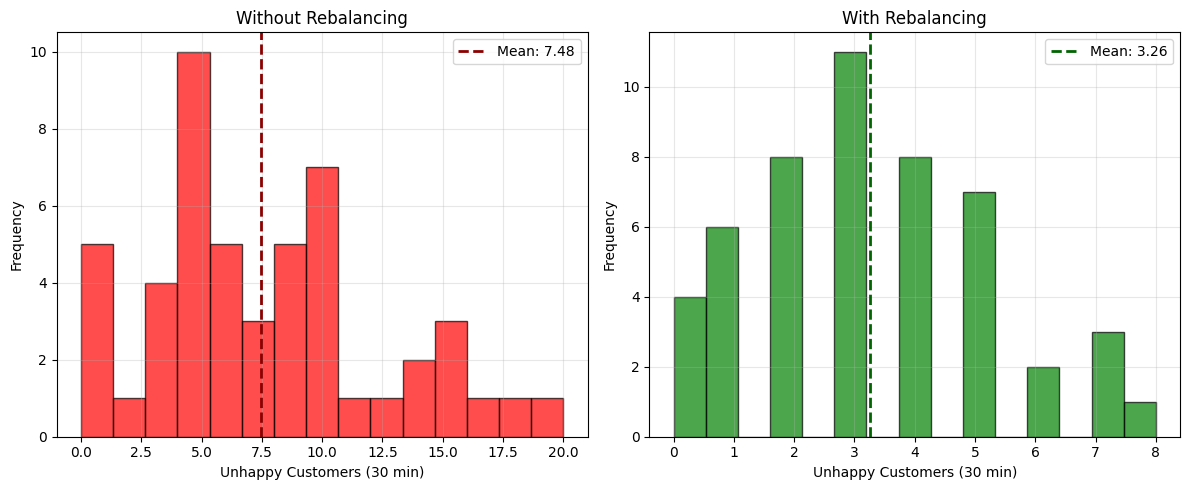

C:\Users\alexc\AppData\Local\Temp\ipykernel_4136\1643367470.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results_without_rebalancing, results_with_rebalancing],


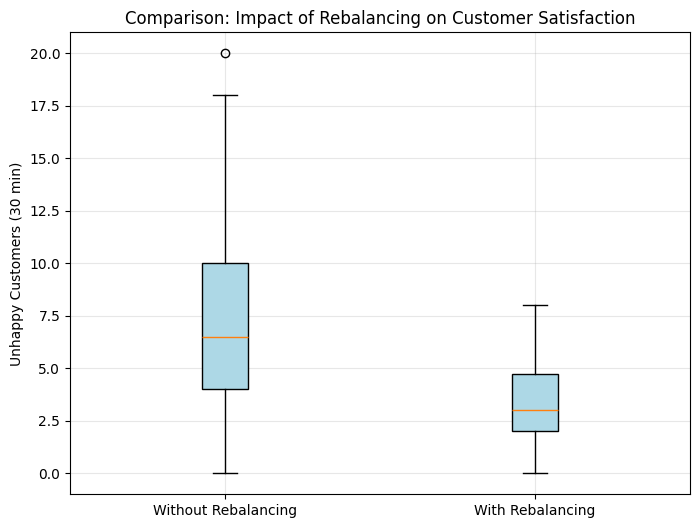

In [56]:

# Function to run a single simulation and return unhappy count
def run_single_simulation(duration=30, with_rebalancing=False):
    env = simpy.Environment()
    
    # Create stations
    upt_station = Station(env, "UPT", capacity=10, init_bikes=5)
    center_station = Station(env, "Center", capacity=10, init_bikes=5)
    p700_station = Station(env, "P700", capacity=8, init_bikes=4)
    stations = [upt_station, center_station, p700_station]
    
    prob_matrix = {
        (upt_station, center_station): 0.3,
        (center_station, upt_station): 0.5,
        (upt_station, p700_station): 0.2,
        (p700_station, upt_station): 0.25,
        (center_station, p700_station): 0.15,
        (p700_station, center_station): 0.2,
    }
    
    # Track unhappy customers
    unhappy_tracker = {'pickup_failed': 0, 'return_failed': 0}
    
    # Start processes
    env.process(generate_trips_variable(env, prob_matrix, unhappy_tracker))
    if with_rebalancing:
        env.process(rebalance_stations(env, stations, rebalance_interval=10))
    
    # Run simulation
    env.run(until=duration)
    
    return unhappy_tracker

# Multi-run simulation
num_runs = 50
results_without_rebalancing = []
results_with_rebalancing = []

print("Running simulations without rebalancing...")
for i in range(num_runs):
    result = run_single_simulation(duration=30, with_rebalancing=False)
    total_unhappy = result['pickup_failed'] + result['return_failed']
    results_without_rebalancing.append(total_unhappy)

print("Running simulations with rebalancing...")
for i in range(num_runs):
    result = run_single_simulation(duration=30, with_rebalancing=True)
    total_unhappy = result['pickup_failed'] + result['return_failed']
    results_with_rebalancing.append(total_unhappy)

# Calculate statistics
import statistics

avg_without = statistics.mean(results_without_rebalancing)
avg_with = statistics.mean(results_with_rebalancing)
std_without = statistics.stdev(results_without_rebalancing)
std_with = statistics.stdev(results_with_rebalancing)

print(f"\n=== Results over {num_runs} runs (30 minutes each) ===")
print(f"Without Rebalancing: Avg unhappy = {avg_without:.2f} +- {std_without:.2f}")
print(f"With Rebalancing:    Avg unhappy = {avg_with:.2f} +- {std_with:.2f}")
print(f"Per hour estimate without: {avg_without * 2:.2f}")
print(f"Per hour estimate with:    {avg_with * 2:.2f}")

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(results_without_rebalancing, bins=15, alpha=0.7, color='red', edgecolor='black')
plt.axvline(avg_without, color='darkred', linestyle='--', linewidth=2, label=f'Mean: {avg_without:.2f}')
plt.xlabel('Unhappy Customers (30 min)')
plt.ylabel('Frequency')
plt.title('Without Rebalancing')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(results_with_rebalancing, bins=15, alpha=0.7, color='green', edgecolor='black')
plt.axvline(avg_with, color='darkgreen', linestyle='--', linewidth=2, label=f'Mean: {avg_with:.2f}')
plt.xlabel('Unhappy Customers (30 min)')
plt.ylabel('Frequency')
plt.title('With Rebalancing')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plot comparison
plt.figure(figsize=(8, 6))
plt.boxplot([results_without_rebalancing, results_with_rebalancing], 
            labels=['Without Rebalancing', 'With Rebalancing'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.ylabel('Unhappy Customers (30 min)')
plt.title('Comparison: Impact of Rebalancing on Customer Satisfaction')
plt.grid(True, alpha=0.3)
plt.show()

### Simulate over multiple runs and analyze average unhappy customers

Time 0: Bike taken from P700 (trip will take 1 min)
Time 1: Bike taken from UPT (trip will take 4 min)
Time 1: Bike taken from Center (trip will take 3 min)
Time 1: Bike returned to UPT
Time 2: Bike taken from Center (trip will take 3 min)
Time 2: Bike taken from P700 (trip will take 3 min)
Time 4: Bike returned to UPT
Time 4: Bike taken from Center (trip will take 1 min)
Time 4: Bike taken from UPT (trip will take 2 min)
Time 4: Bike taken from P700 (trip will take 1 min)
Time 4: Bike taken from P700 (trip will take 1 min)
Time 5: Bike returned to Center
Time 5: Bike returned to UPT
Time 5: Bike returned to UPT
Time 5: Bike returned to UPT
Time 5: Bike returned to UPT
Time 5: Bike returned to Center
Time 6: Bike returned to P700
Time 8: Bike taken from UPT (trip will take 3 min)
Time 8: Bike taken from Center (trip will take 3 min)
Time 8: Bike taken from UPT (trip will take 3 min)
Time 8: Bike taken from P700 (trip will take 2 min)
Time 10: Bike returned to UPT
Time 10: Bike taken fr

C:\Users\alexc\AppData\Local\Temp\ipykernel_4136\518881062.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([results_without, results_with], labels=['Without Rebalancing', 'With Rebalancing'])


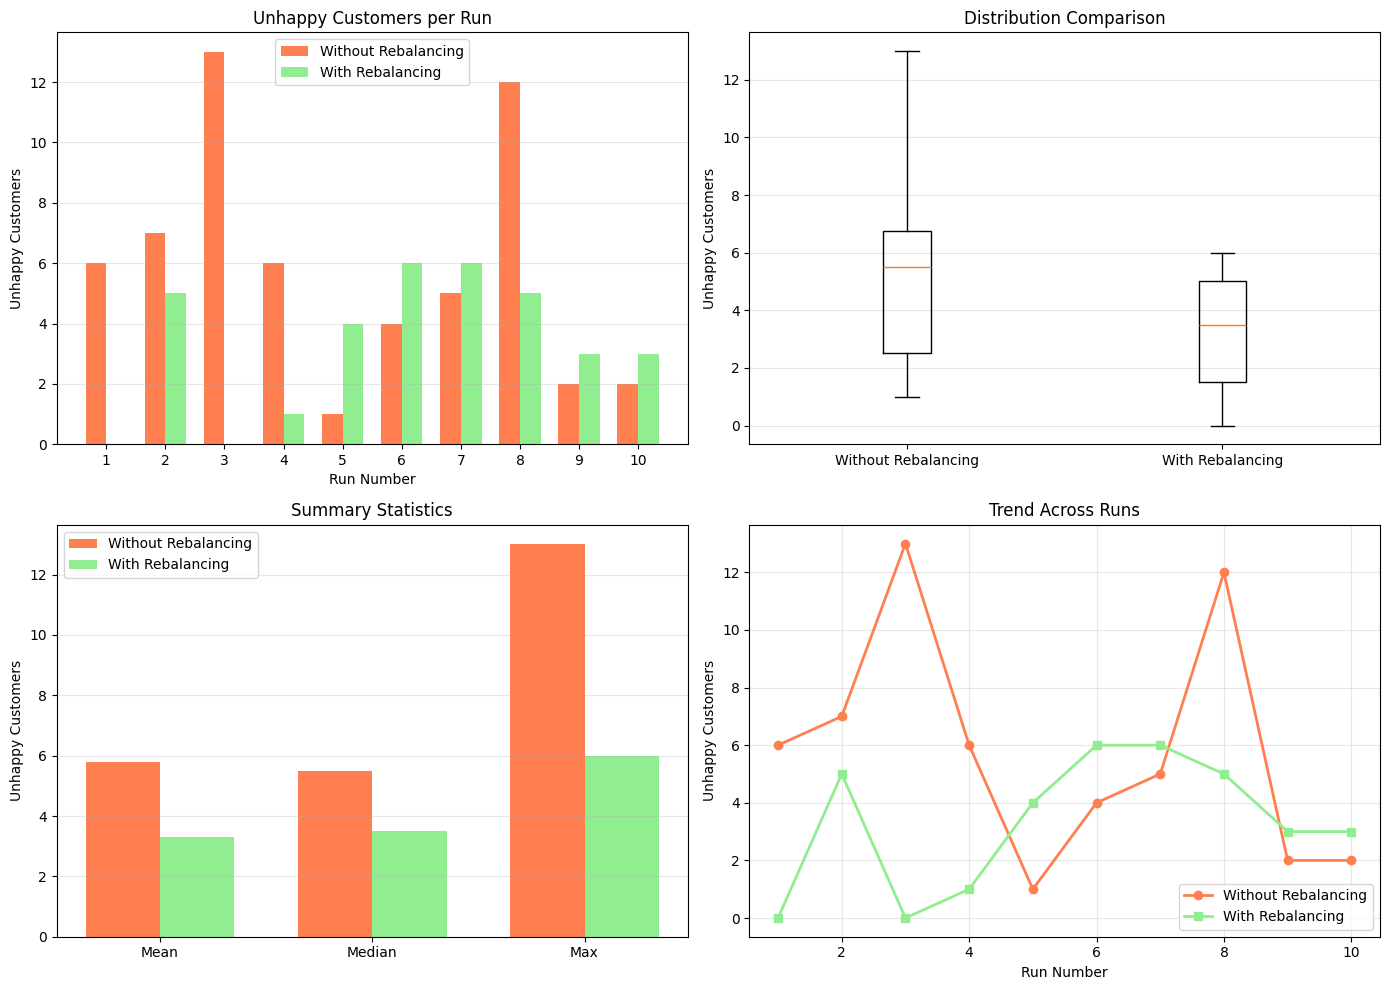


SIMULATION SUMMARY (10 runs each)

Without Rebalancing:
  Mean: 5.80
  Std Dev: 4.05
  Min: 1, Max: 13

With Rebalancing:
  Mean: 3.30
  Std Dev: 2.31
  Min: 0, Max: 6

Improvement: 2.50 unhappy customers (43.1%)


In [65]:
# Write your multi-run simulation & plotting code below
import numpy as np
import matplotlib.pyplot as plt
import statistics

# Configuration for simulations
num_runs = 10

# Run 10 simulations WITHOUT rebalancing
results_without = []
for _ in range(num_runs):
    env = simpy.Environment()
    
    upt = Station(env, "UPT", capacity=10, init_bikes=5)
    center = Station(env, "Center", capacity=10, init_bikes=5)
    p700 = Station(env, "P700", capacity=8, init_bikes=4)
    
    prob_matrix = {
        (upt, center): 0.3,
        (center, upt): 0.5,
        (upt, p700): 0.2,
        (p700, upt): 0.25,
        (center, p700): 0.15,
        (p700, center): 0.2,
    }
    
    unhappy_tracker = {'pickup_failed': 0, 'return_failed': 0}
    env.process(generate_trips_variable(env, prob_matrix, unhappy_tracker))
    env.run(until=30)
    
    results_without.append(unhappy_tracker['pickup_failed'] + unhappy_tracker['return_failed'])

# Run 10 simulations WITH rebalancing
results_with = []
for _ in range(num_runs):
    env = simpy.Environment()
    
    upt = Station(env, "UPT", capacity=10, init_bikes=5)
    center = Station(env, "Center", capacity=10, init_bikes=5)
    p700 = Station(env, "P700", capacity=8, init_bikes=4)
    stations = [upt, center, p700]
    
    prob_matrix = {
        (upt, center): 0.3,
        (center, upt): 0.5,
        (upt, p700): 0.2,
        (p700, upt): 0.25,
        (center, p700): 0.15,
        (p700, center): 0.2,
    }
    
    unhappy_tracker = {'pickup_failed': 0, 'return_failed': 0}
    env.process(generate_trips_variable(env, prob_matrix, unhappy_tracker))
    env.process(rebalance_stations(env, stations, rebalance_interval=10))
    env.run(until=30)
    
    results_with.append(unhappy_tracker['pickup_failed'] + unhappy_tracker['return_failed'])

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart comparing individual runs
ax1 = axes[0, 0]
x = np.arange(num_runs)
width = 0.35
ax1.bar(x - width/2, results_without, width, label='Without Rebalancing', color='coral')
ax1.bar(x + width/2, results_with, width, label='With Rebalancing', color='lightgreen')
ax1.set_xlabel('Run Number')
ax1.set_ylabel('Unhappy Customers')
ax1.set_title('Unhappy Customers per Run')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{i+1}' for i in range(num_runs)])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Box plot comparison
ax2 = axes[0, 1]
ax2.boxplot([results_without, results_with], labels=['Without Rebalancing', 'With Rebalancing'])
ax2.set_ylabel('Unhappy Customers')
ax2.set_title('Distribution Comparison')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Summary statistics bar chart
ax3 = axes[1, 0]
categories = ['Mean', 'Median', 'Max']
without_stats = [statistics.mean(results_without), statistics.median(results_without), max(results_without)]
with_stats = [statistics.mean(results_with), statistics.median(results_with), max(results_with)]
x_pos = np.arange(len(categories))
ax3.bar(x_pos - width/2, without_stats, width, label='Without Rebalancing', color='coral')
ax3.bar(x_pos + width/2, with_stats, width, label='With Rebalancing', color='lightgreen')
ax3.set_ylabel('Unhappy Customers')
ax3.set_title('Summary Statistics')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(categories)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Line plot showing trend
ax4 = axes[1, 1]
ax4.plot(range(1, num_runs+1), results_without, marker='o', label='Without Rebalancing', color='coral', linewidth=2)
ax4.plot(range(1, num_runs+1), results_with, marker='s', label='With Rebalancing', color='lightgreen', linewidth=2)
ax4.set_xlabel('Run Number')
ax4.set_ylabel('Unhappy Customers')
ax4.set_title('Trend Across Runs')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*50}")
print(f"SIMULATION SUMMARY ({num_runs} runs each)")
print(f"{'='*50}")
print(f"\nWithout Rebalancing:")
print(f"  Mean: {statistics.mean(results_without):.2f}")
print(f"  Std Dev: {statistics.stdev(results_without):.2f}")
print(f"  Min: {min(results_without)}, Max: {max(results_without)}")

print(f"\nWith Rebalancing:")
print(f"  Mean: {statistics.mean(results_with):.2f}")
print(f"  Std Dev: {statistics.stdev(results_with):.2f}")
print(f"  Min: {min(results_with)}, Max: {max(results_with)}")

improvement = statistics.mean(results_without) - statistics.mean(results_with)
print(f"\nImprovement: {improvement:.2f} unhappy customers ({improvement/statistics.mean(results_without)*100:.1f}%)")


Ideas of things that can be analyzed to assess impact on results

* Change the initial number of bikes at each station.
* Adjust the trip probabilities in the prob_matrix.
* Add more stations or different rebalancing strategies.